In [2]:
import numpy as np
import pandas as pd
from mplsoccer import Pitch, VerticalPitch
import matplotlib.pyplot as plt

In [3]:
# load data
data = pd.read_csv("../data/full_data.csv")
data.head()

C:\Users\miale.a\AppData\Local\Temp\ipykernel_17440\3577333053.py:2: DtypeWarning: Columns (27) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("../data/full_data.csv")


,Unnamed: 0,player_id_event,match_id,frame_start,frame_end,event_id,event_type,team_id_event,player_in_possession_id,x_start,...,number,team_id_tracking,team_name,player_role.position_group,total_time,player_role.name,player_role.acronym,is_gk,direction_player_1st_half,direction_player_2nd_half
0,0,966120,1886347,28,28,8_0,player_possession,1805,NaN,0.73,...,1,1805,Newcastle United Jets FC,Other,5400,Goalkeeper,GK,True,left_to_right,right_to_left
1,1,966120,1886347,28,28,8_0,player_possession,1805,NaN,0.73,...,4,1805,Newcastle United Jets FC,Central Defender,5400,Right Center Back,RCB,False,left_to_right,right_to_left
2,2,966120,1886347,28,28,8_0,player_possession,1805,NaN,0.73,...,15,1805,Newcastle United Jets FC,Central Defender,5400,Left Center Back,LCB,False,left_to_right,right_to_left
3,3,966120,1886347,28,28,8_0,player_possession,1805,NaN,0.73,...,14,1805,Newcastle United Jets FC,Full Back,5400,Right Back,RB,False,left_to_right,right_to_left
4,4,966120,1886347,28,28,8_0,player_possession,1805,NaN,0.73,...,33,1805,Newcastle United Jets FC,Full Back,5400,Left Back,LB,False,left_to_right,right_to_left


In [4]:
print(data.columns.tolist())

['Unnamed: 0', 'player_id_event', 'match_id', 'frame_start', 'frame_end', 'event_id', 'event_type', 'team_id_event', 'player_in_possession_id', 'x_start', 'y_start', 'x_end', 'y_end', 'x', 'y', 'player_id_tracking', 'is_detected', 'frame', 'timestamp', 'period', 'possession_player_id', 'possession_group', 'ball_x', 'ball_y', 'ball_z', 'is_detected_ball', 'start_time', 'end_time', 'match_name', 'date_time', 'home_team.name', 'away_team.name', 'id', 'short_name', 'number', 'team_id_tracking', 'team_name', 'player_role.position_group', 'total_time', 'player_role.name', 'player_role.acronym', 'is_gk', 'direction_player_1st_half', 'direction_player_2nd_half']


In [5]:
print(data["frame_start"].value_counts())

frame_start
10770    264
5804     264
11649    264
44221    264
3890     242
        ... 
47543     22
45439     22
69737     22
69743     22
69747     22
Name: count, Length: 24929, dtype: int64


In [6]:
# get some columns
print(data[data["frame_start"]==45439][["timestamp", "date_time"]])

                      timestamp             date_time
415712  2026-03-31 01:12:26.800  2024-12-31T08:00:00Z
415713  2026-03-31 01:12:26.800  2024-12-31T08:00:00Z
415714  2026-03-31 01:12:26.800  2024-12-31T08:00:00Z
415715  2026-03-31 01:12:26.800  2024-12-31T08:00:00Z
415716  2026-03-31 01:12:26.800  2024-12-31T08:00:00Z
415717  2026-03-31 01:12:26.800  2024-12-31T08:00:00Z
415718  2026-03-31 01:12:26.800  2024-12-31T08:00:00Z
415719  2026-03-31 01:12:26.800  2024-12-31T08:00:00Z
415720  2026-03-31 01:12:26.800  2024-12-31T08:00:00Z
415721  2026-03-31 01:12:26.800  2024-12-31T08:00:00Z
415722  2026-03-31 01:12:26.800  2024-12-31T08:00:00Z
415723  2026-03-31 01:12:26.800  2024-12-31T08:00:00Z
415724  2026-03-31 01:12:26.800  2024-12-31T08:00:00Z
415725  2026-03-31 01:12:26.800  2024-12-31T08:00:00Z
415726  2026-03-31 01:12:26.800  2024-12-31T08:00:00Z
415727  2026-03-31 01:12:26.800  2024-12-31T08:00:00Z
415728  2026-03-31 01:12:26.800  2024-12-31T08:00:00Z
415729  2026-03-31 01:12:26.

In [49]:
test = data[data["frame_start"]==45439][["x", "y", "ball_x", "ball_y", "number", "team_id_tracking", "frame", "timestamp", "possession_group"]]

In [34]:
# convert teams to 0/1
test["team_id_tracking"] = list(map(lambda test: 1 if test==2380 else 0, test["team_id_tracking"]))
print(test["team_id_tracking"])

415712    1
415713    1
415714    1
415715    1
415716    1
415717    1
415718    1
415719    1
415720    1
415721    1
415722    1
415723    0
415724    0
415725    0
415726    0
415727    0
415728    0
415729    0
415730    0
415731    0
415732    0
415733    0
Name: team_id_tracking, dtype: int64


In [52]:
print(test["possession_group"])

415712    home team
415713    home team
415714    home team
415715    home team
415716    home team
415717    home team
415718    home team
415719    home team
415720    home team
415721    home team
415722    home team
415723    home team
415724    home team
415725    home team
415726    home team
415727    home team
415728    home team
415729    home team
415730    home team
415731    home team
415732    home team
415733    home team
Name: possession_group, dtype: object


In [35]:
# get x and y for each team
x1 = test[test["team_id_tracking"]==1]["x"]
y1 = test[test["team_id_tracking"]==1]["y"]
x2 = test[test["team_id_tracking"]!=1]["x"]
y2 = test[test["team_id_tracking"]!=1]["y"]

In [40]:
# get individual list of each column
x = test["x"].tolist()
y = test["y"].tolist()
ball_x = test["ball_x"].iloc[0]
ball_y = test["ball_y"].iloc[0]
numbers = test["number"].tolist()
team_id = test["team_id_tracking"].tolist()

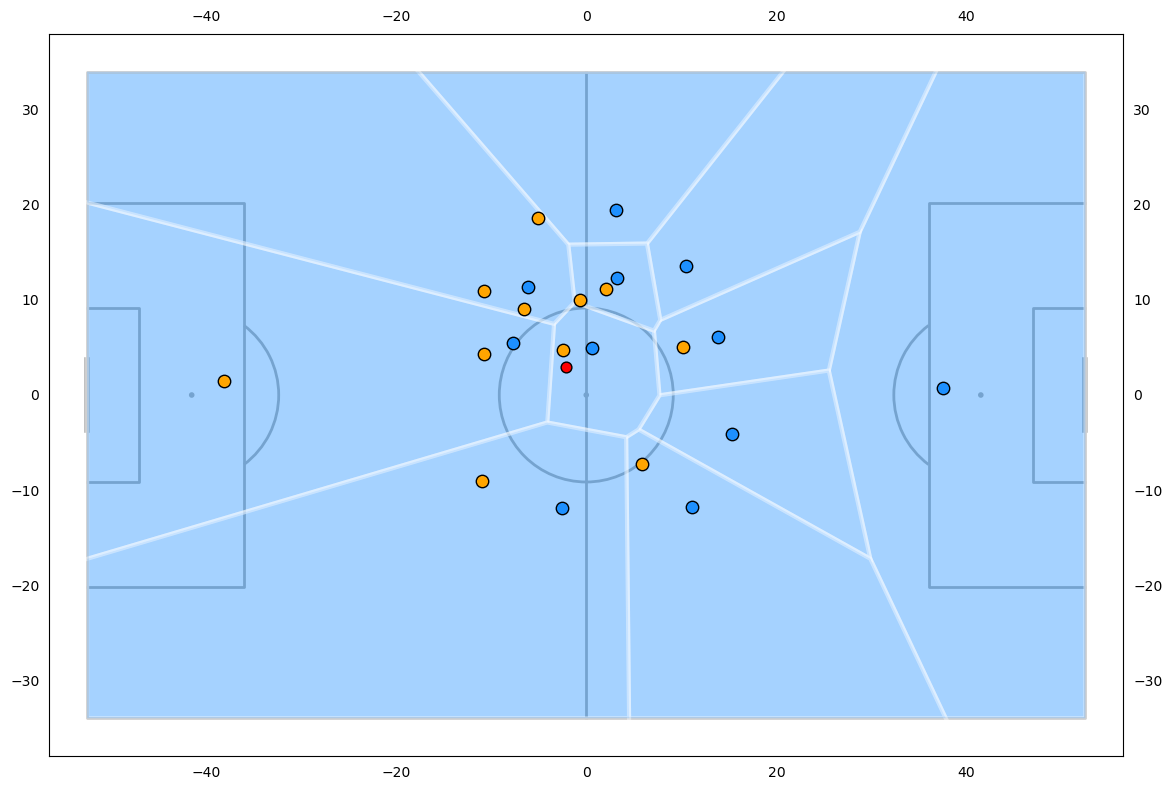

In [54]:
# plot voronoi of snapshot
p = Pitch(pitch_type="skillcorner", pitch_length=105, pitch_width=68, axis=True, label=True)
fig, ax = p.draw(figsize=(12,8))

# Plot Voronoi
team1, team2 = p.voronoi(x2, y2, team_id[11:23])
t1 = p.polygon(team1, ax=ax, fc='orange', ec='white', lw=3, alpha=0.4)
t2 = p.polygon(team2, ax=ax, fc='dodgerblue', ec='white', lw=3, alpha=0.4)

# Plot players
sc1 = p.scatter(x1, y1, c='orange', s=80, ec='k', ax=ax)
sc2 = p.scatter(x2, y2, c='dodgerblue', s=80, ec='k', ax=ax)
ball = p.scatter(ball_x, ball_y, c='red', s=60, ec='k', ax=ax)

In [12]:
print(team1)

[array([[-31.44986334,   9.07715261],
        [-31.02848106,  -7.25356038],
        [-42.73786717, -34.        ],
        [-52.5       , -34.        ],
        [-52.5       ,  34.        ],
        [-50.83161165,  34.        ]])
 array([[-16.18847269,  -3.65278677],
        [-31.02848106,  -7.25356038],
        [-42.73786717, -34.        ],
        [-25.84792135, -34.        ],
        [-17.53222774, -27.35810626],
        [-10.54970685, -15.63055735]])
 array([[-16.18847269,  -3.65278677],
        [-31.02848106,  -7.25356038],
        [-31.44986334,   9.07715261],
        [-15.83497778,   7.45835249],
        [-13.58046911,   2.36644583]])
 array([[  6.12960229, -26.50899753],
        [-17.53222774, -27.35810626],
        [-25.84792135, -34.        ],
        [ 19.24088106, -34.        ],
        [ 17.81113262, -32.62331752]])
 array([[-10.38676348,  15.8721289 ],
        [-13.18739096,  34.        ],
        [-50.83161165,  34.        ],
        [-31.44986334,   9.07715261],
        

In [15]:
from shapely import Polygon

In [24]:
poly = Polygon(team1[0])
print(poly.area)

1048.004133169468
